In [1]:
# For Data Processing
import numpy as np
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from PIL import Image, ImageEnhance

# For ML Models
from tensorflow import keras
from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.models import *
from tensorflow.keras.metrics import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.applications import *
from tensorflow.keras.preprocessing.image import load_img

# For Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Miscellaneous
from tqdm import tqdm
import os
import random

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: l

In [2]:
train_dir = '/kaggle/input/brain-tumor-mri-dataset/Training/'
test_dir = '/kaggle/input/brain-tumor-mri-dataset/Testing/'

train_paths = []
train_labels = []

for label in os.listdir(train_dir):
    for image in os.listdir(train_dir+label):
        train_paths.append(train_dir+label+'/'+image)
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

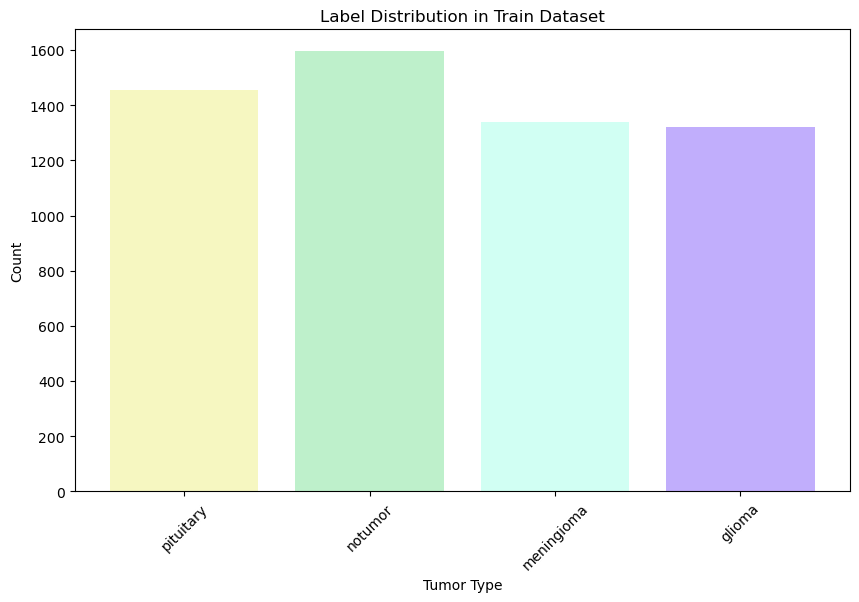

In [3]:
labels = ['pituitary', 'notumor', 'meningioma', 'glioma']
counts = [
    len([x for x in train_labels if x == 'pituitary']),
    len([x for x in train_labels if x == 'notumor']),
    len([x for x in train_labels if x == 'meningioma']),
    len([x for x in train_labels if x == 'glioma'])
]

# Bar chart
plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color=['#F6F7C1', '#BEF0CB', '#D1FFF3', '#C1AEFC'])
plt.title('Label Distribution in Train Dataset')
plt.ylabel('Count')
plt.xlabel('Tumor Type')
plt.xticks(rotation=45)
plt.show()

In [4]:
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
    for image in os.listdir(test_dir+label):
        test_paths.append(test_dir+label+'/'+image)
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

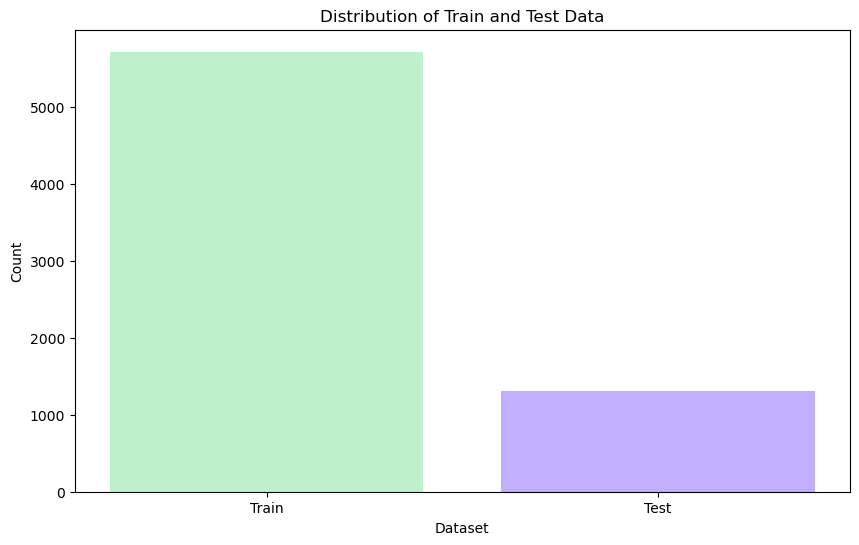

In [5]:
import matplotlib.pyplot as plt

# Counts of train and test datasets
data_labels = ['Train', 'Test']
data_counts = [len(train_labels), len(test_labels)]

# Bar chart
plt.figure(figsize=(10, 6))
plt.bar(data_labels, data_counts, color=['#BEF0CB', '#C1AEFC'])
plt.title('Distribution of Train and Test Data')
plt.ylabel('Count')
plt.xlabel('Dataset')
plt.show()


In [6]:
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8,1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8,1.2))
    image = np.array(image)/255.0
    return image

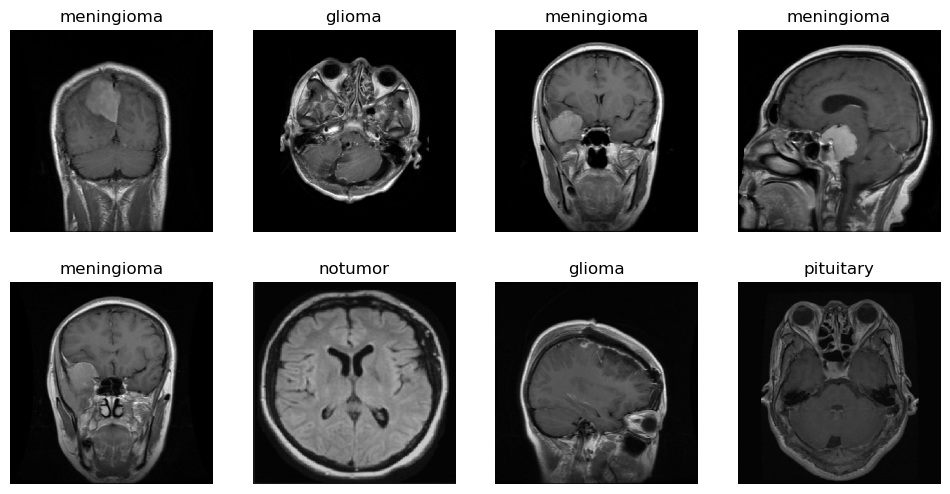

In [7]:
IMAGE_SIZE = 299

def open_images(paths):
    '''
    Given a list of paths to images, this function returns the images as arrays (after augmenting them)
    '''
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE,IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

images = open_images(train_paths[50:59])
labels = train_labels[50:59]
fig = plt.figure(figsize=(12, 6))
for x in range(1, 9):
    fig.add_subplot(2, 4, x)
    plt.axis('off')
    plt.title(labels[x])
    plt.imshow(images[x])
plt.rcParams.update({'font.size': 20})
plt.show()

In [8]:
unique_labels = os.listdir(train_dir)

def encode_label(labels):
    encoded = []
    for x in labels:
        encoded.append(unique_labels.index(x))
    return np.array(encoded)

def decode_label(labels):
    decoded = []
    for x in labels:
        decoded.append(unique_labels[x])
    return np.array(decoded)

def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for x in range(0, len(paths), batch_size):
            batch_paths = paths[x:x+batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[x:x+batch_size]
            batch_labels = encode_label(batch_labels)
            yield batch_images, batch_labels

In [10]:
img_shape = (299, 299, 3)

In [11]:
base_model = Xception(include_top=False, weights="imagenet", input_shape=img_shape, pooling='max')

# Freeze the base model
base_model.trainable = False

# Define the model
inputs = Input(shape=img_shape)
x = base_model(inputs)
x = Flatten()(x)
x = Dropout(rate=0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(rate=0.25)(x)
x = Dense(4, activation='softmax')(x)  # Adjust the number of classes as needed

model = Model(inputs, x)

# Compile the model
model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

# Summary of the model
model.summary()

83683744/83683744 [==============================] - 0s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 299, 299, 3)]     0         
                                                                 
 xception (Functional)       (None, 2048)              20861480  
                                                                 
 flatten (Flatten)           (None, 2048)              0         
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 128)               262272    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                              

In [22]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 299, 299, 3)]     0         
                                                                 
 xception (Functional)       (None, 2048)              20861480  
                                                                 
 flatten (Flatten)           (None, 2048)              0         
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 128)               262272    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 4)                 516   

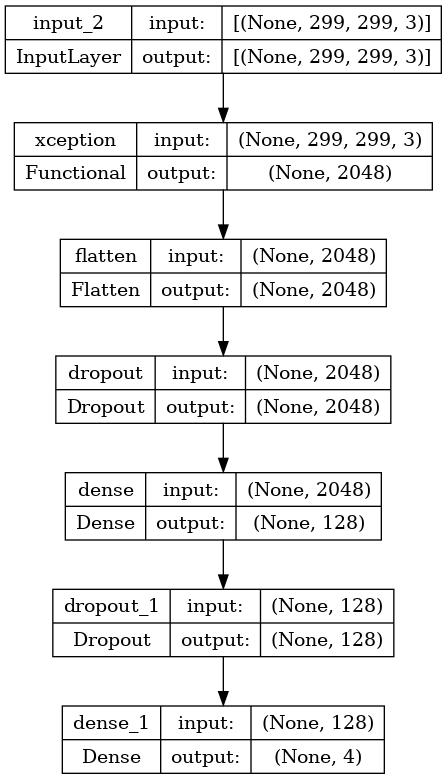

In [12]:
keras.utils.plot_model(model, show_shapes=True)

In [13]:
model.compile(optimizer=Adam(learning_rate=0.0001),
             loss='sparse_categorical_crossentropy',
             metrics=['sparse_categorical_accuracy'])

In [15]:
# batch_size = 20
# steps = int(len(train_paths)/batch_size)
# epochs = 10
# history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
#                     epochs=epochs, steps_per_epoch=steps)

import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Check if GPU is available
device_name = tf.test.gpu_device_name()
if device_name:
    print(f"Using GPU: {device_name}")
else:
    print("GPU is not available. Ensure GPU is enabled in Kaggle settings.")

# Training parameters
batch_size = 20
steps = len(train_paths) // batch_size
epochs = 10

# Callbacks for better training
checkpoint = ModelCheckpoint(
    'best_model.keras', save_best_only=True, monitor='val_loss', mode='min'
)
early_stopping = EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

# Start training
history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    epochs=epochs,
    steps_per_epoch=steps,
    validation_data=datagen(test_paths, test_labels, batch_size=batch_size, epochs=epochs),
    validation_steps=len(test_paths) // batch_size,
    callbacks=[checkpoint, early_stopping]
)


Using GPU: /device:GPU:0
Epoch 1/10
285/285 [==============================] - 85s 268ms/step - loss: 0.9359 - sparse_categorical_accuracy: 0.6367 - val_loss: 0.5606 - val_sparse_categorical_accuracy: 0.7808
Epoch 2/10
285/285 [==============================] - 61s 212ms/step - loss: 0.5526 - sparse_categorical_accuracy: 0.7874 - val_loss: 0.4716 - val_sparse_categorical_accuracy: 0.8169
Epoch 3/10
285/285 [==============================] - 59s 206ms/step - loss: 0.4655 - sparse_categorical_accuracy: 0.8234 - val_loss: 0.4314 - val_sparse_categorical_accuracy: 0.8277
Epoch 4/10
285/285 [==============================] - 59s 209ms/step - loss: 0.4125 - sparse_categorical_accuracy: 0.8465 - val_loss: 0.3825 - val_sparse_categorical_accuracy: 0.8500
Epoch 5/10
285/285 [==============================] - 59s 209ms/step - loss: 0.3820 - sparse_categorical_accuracy: 0.8505 - val_loss: 0.3555 - val_sparse_categorical_accuracy: 0.8700
Epoch 6/10
285/285 [==============================] - 59s 20

Federated Learning

In [20]:
# import tensorflow as tf
# import numpy as np
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

# # Define the number of clients and the number of training rounds
# NUM_CLIENTS = 10
# NUM_ROUNDS = 3


# # Define the clients and their data
# clients = []
# for i in range(NUM_CLIENTS):
#     client_data = train_paths[i * (len(train_paths) // NUM_CLIENTS):(i + 1) * (len(train_paths) // NUM_CLIENTS)]
#     client_labels = train_labels[i * (len(train_labels) // NUM_CLIENTS):(i + 1) * (len(train_labels) // NUM_CLIENTS)]
#     clients.append((client_data, client_labels))

# # Federated learning loop
# for round_num in range(NUM_ROUNDS):

#     # Select clients
#     selected_client_indices = np.random.choice(len(clients), size=int(NUM_CLIENTS * 0.5), replace=False)
#     selected_clients = [clients[i] for i in selected_client_indices]

#     # Transmit the global model to the selected clients
#     for client in selected_clients:
#         client_model = tf.keras.models.clone_model(model)
#         client_model.set_weights(model.get_weights())
  
#         # Compile the client model
#         client_model.compile(optimizer=Adam(learning_rate=0.0001),
#         loss='sparse_categorical_crossentropy',
#         metrics=['sparse_categorical_accuracy'])

#         steps_per_epoch = int(len(client[0]) / 20)
        

#         client_model.fit(datagen(client[0],client[1], batch_size=batch_size, epochs=epochs),
#                          epochs=5, steps_per_epoch=steps_per_epoch)

#         # Train locally
#         steps_per_epoch = int(len(client[0]) / 20)

#         # Aggregate the model
#         new_weights = []
#         for layer_index in range(len(model.get_weights())):
#             new_layer_weights = np.mean([client_model.get_weights()[layer_index], model.get_weights()[layer_index]], axis=0)
#             new_weights.append(new_layer_weights)
#         model.set_weights(new_weights)

        
# batch_size = 32
# steps = int(len(test_paths)/batch_size)
# y_pred = []
# y_true = []
# for x,y in tqdm(datagen(test_paths, test_labels, batch_size=batch_size, epochs=1), total=steps):
#     pred = model.predict(x)
#     pred = np.argmax(pred, axis=-1)
#     for i in decode_label(pred):
#         y_pred.append(i)
#     for i in decode_label(y):
#         y_true.append(i)





# model.save('federated_model.keras')

import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tqdm import tqdm

# Define the number of clients and the number of training rounds
NUM_CLIENTS = 10
NUM_ROUNDS = 3

# Define the clients and their data
clients = []
for i in range(NUM_CLIENTS):
    client_data = train_paths[i * (len(train_paths) // NUM_CLIENTS):(i + 1) * (len(train_paths) // NUM_CLIENTS)]
    client_labels = train_labels[i * (len(train_labels) // NUM_CLIENTS):(i + 1) * (len(train_labels) // NUM_CLIENTS)]
    clients.append((client_data, client_labels))

# Federated learning loop
for round_num in range(NUM_ROUNDS):
    print(f"\n=== Federated Learning Round {round_num + 1} / {NUM_ROUNDS} ===")

    # Select clients
    selected_client_indices = np.random.choice(len(clients), size=int(NUM_CLIENTS * 0.5), replace=False)
    selected_clients = [clients[i] for i in selected_client_indices]

    print(f"Selected Clients for Round {round_num + 1}: {selected_client_indices}")

    # Transmit the global model to the selected clients
    for client_idx, client in enumerate(selected_clients):
        print(f"\n--- Training Client {selected_client_indices[client_idx]} ---")
        
        # Clone and set global model weights
        client_model = tf.keras.models.clone_model(model)
        client_model.set_weights(model.get_weights())
        
        # Compile the client model
        client_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
            loss='sparse_categorical_crossentropy',
            metrics=['sparse_categorical_accuracy']
        )
        
        steps_per_epoch = int(len(client[0]) / 20)
        
        print(f"Training Client {selected_client_indices[client_idx]} - Steps Per Epoch: {steps_per_epoch}, Epochs: 5")
        
        # Train locally
        client_model.fit(
            datagen(client[0], client[1], batch_size=batch_size, epochs=5),
            epochs=5,
            steps_per_epoch=steps_per_epoch
        )
        
        print(f"Completed Training for Client {selected_client_indices[client_idx]}")

        # Aggregate the model
        print(f"Aggregating Model for Client {selected_client_indices[client_idx]}...")
        new_weights = []
        for layer_index in range(len(model.get_weights())):
            new_layer_weights = np.mean(
                [client_model.get_weights()[layer_index], model.get_weights()[layer_index]],
                axis=0
            )
            new_weights.append(new_layer_weights)
        model.set_weights(new_weights)

    print(f"Completed Aggregation for Round {round_num + 1}")

# Evaluate the model
batch_size = 32
steps = int(len(test_paths) / batch_size)
y_pred = []
y_true = []

print("\n=== Evaluating the Model on Test Data ===")
for x, y in tqdm(datagen(test_paths, test_labels, batch_size=batch_size, epochs=1), total=steps):
    pred = model.predict(x)
    pred = np.argmax(pred, axis=-1)
    for i in decode_label(pred):
        y_pred.append(i)
    for i in decode_label(y):
        y_true.append(i)

# Save the model
model.save('federated_model.keras')
print("\nModel saved as 'federated_model.keras'")



=== Federated Learning Round 1 / 3 ===
Selected Clients for Round 1: [9 3 2 4 6]

--- Training Client 9 ---
Training Client 9 - Steps Per Epoch: 28, Epochs: 5
Epoch 1/5
28/28 [==============================] - 8s 165ms/step - loss: 0.2722 - sparse_categorical_accuracy: 0.9036
Epoch 2/5
28/28 [==============================] - 5s 171ms/step - loss: 0.2369 - sparse_categorical_accuracy: 0.9020
Epoch 3/5
28/28 [==============================] - 5s 171ms/step - loss: 0.2544 - sparse_categorical_accuracy: 0.9093
Epoch 4/5
28/28 [==============================] - 5s 175ms/step - loss: 0.2218 - sparse_categorical_accuracy: 0.9093
Epoch 5/5
28/28 [==============================] - 5s 178ms/step - loss: 0.1965 - sparse_categorical_accuracy: 0.9165
Completed Training for Client 9
Aggregating Model for Client 9...

--- Training Client 3 ---
Training Client 3 - Steps Per Epoch: 28, Epochs: 5
Epoch 1/5
28/28 [==============================] - 7s 164ms/step - loss: 0.2850 - sparse_categorical_accur

  0%|          | 0/40 [00:00<?, ?it/s]

1/1 [==============================] - 4s 4s/step


  2%|▎         | 1/40 [00:04<02:58,  4.59s/it]

1/1 [==============================] - 0s 38ms/step


...

1/1 [==============================] - 0s 39ms/step


100%|██████████| 40/40 [00:28<00:00,  1.59it/s]

1/1 [==============================] - 4s 4s/step


41it [00:33,  1.22it/s]                        



Model saved as 'federated_model.keras'


In [21]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

      glioma       0.93      0.85      0.89       300
  meningioma       0.83      0.82      0.83       306
     notumor       0.96      0.98      0.97       405
   pituitary       0.91      0.97      0.94       300

    accuracy                           0.91      1311
   macro avg       0.91      0.91      0.91      1311
weighted avg       0.91      0.91      0.91      1311



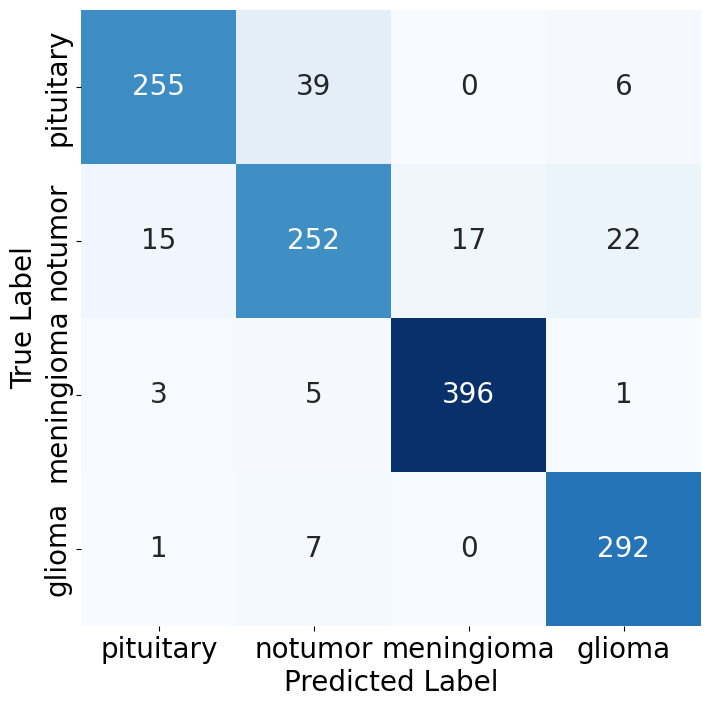

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np




cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=unique_labels, yticklabels=unique_labels, cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()



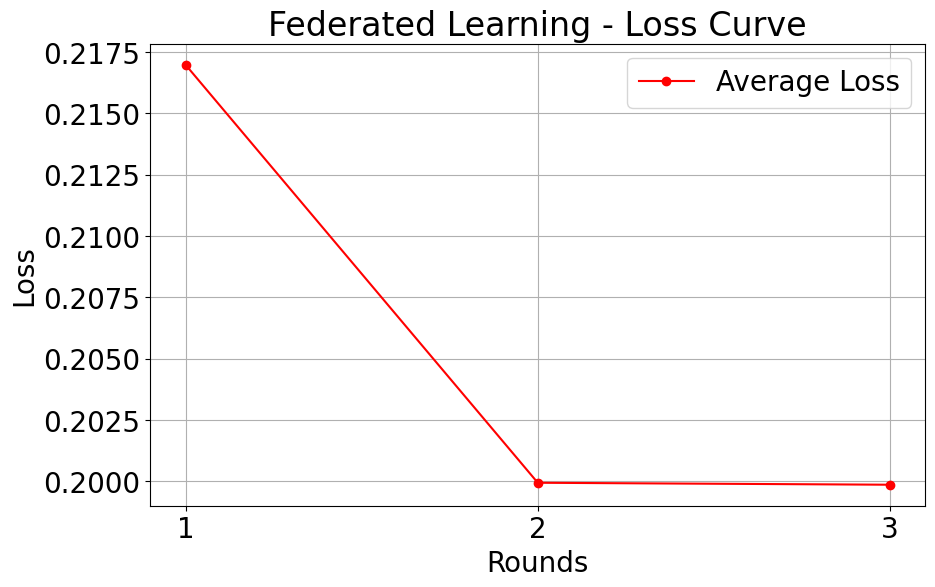

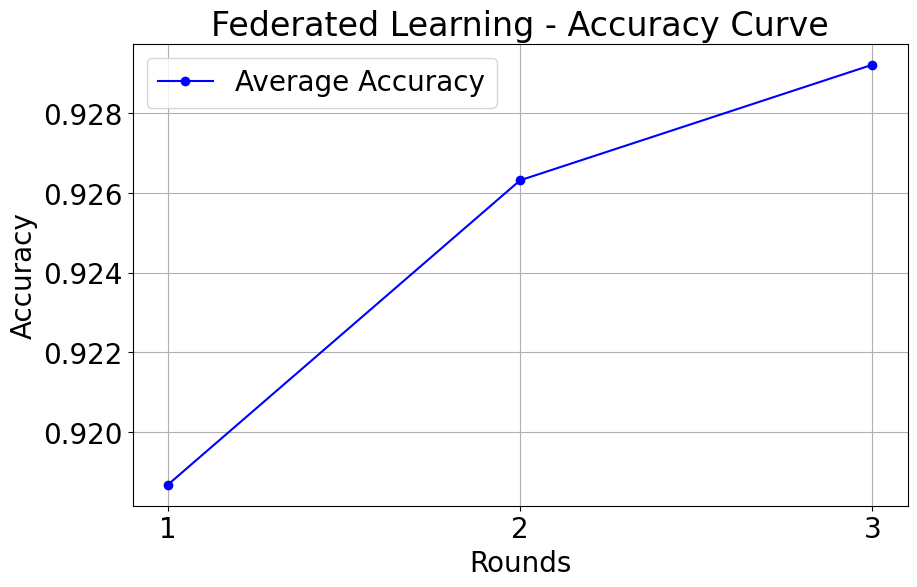

In [28]:
import matplotlib.pyplot as plt

# Extracted final loss and accuracy for each client in each round
losses_per_round = {
    1: [0.1965, 0.2428, 0.1971, 0.2180, 0.2305],  # Round 1
    2: [0.2053, 0.2000, 0.1778, 0.1778, 0.2388],  # Round 2
    3: [0.1994, 0.1905, 0.2367, 0.1814, 0.1913],  # Round 3
}
accuracies_per_round = {
    1: [0.9165, 0.9074, 0.9274, 0.9165, 0.9256],  # Round 1
    2: [0.9238, 0.9238, 0.9310, 0.9347, 0.9183],  # Round 2
    3: [0.9292, 0.9347, 0.9201, 0.9347, 0.9274],  # Round 3
}

# Calculate average loss and accuracy for each round
average_losses = [sum(losses) / len(losses) for losses in losses_per_round.values()]
average_accuracies = [sum(acc) / len(acc) for acc in accuracies_per_round.values()]

# Rounds
rounds = list(losses_per_round.keys())

# Plotting the Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(rounds, average_losses, marker='o', label='Average Loss', color='red')
plt.title('Federated Learning - Loss Curve')
plt.xlabel('Rounds')
plt.ylabel('Loss')
plt.xticks(rounds)
plt.grid(True)
plt.legend()
plt.show()

# Plotting the Accuracy Curve
plt.figure(figsize=(10, 6))
plt.plot(rounds, average_accuracies, marker='o', label='Average Accuracy', color='blue')
plt.title('Federated Learning - Accuracy Curve')
plt.xlabel('Rounds')
plt.ylabel('Accuracy')
plt.xticks(rounds)
plt.grid(True)
plt.legend()
plt.show()
